# NASA AirFoil Self-Noise Dataset

## Introducción

Elijo este dataset para el TP de AM1 acorde a que es mi área de estudio de carrera de grado. Yo soy Ingeniero Industrial Mecánico especializado en Fluidos y Energía, y el estudio del perfil aerodinámico fue central en el desarrollo de la carrera. Al iniciar mi especialización en Inteligencia Artificial, uno de mis objetivos era integrar ambos campos de conocimiento y enriquecerlos mutuamente.

De esta manera, la idea es que el análisis de datos sea complementado con análisis teórico del experimento.

## Dataset

Conjunto de datos de la NASA obtenido de una serie de pruebas aerodinámicas y acústicas de secciones de alas bidimensionales y tridimensionales realizadas en un túnel de viento anecoico. El conjunto de datos de la NASA comprende perfiles aerodinámicos de diferentes tamaños a varias velocidades de túnel de viento y ángulos de ataque. Se busca predecir el valor del nivel de presión sonora, en decibeles (SSPL).

Link al dataset: [https://www.kaggle.com/datasets/fedesoriano/airfoil-selfnoise-dataset/](https://www.kaggle.com/datasets/fedesoriano/airfoil-selfnoise-dataset/)

Este dataset comprende un ensayo de laboratorio de 1989 ([Referencia](https://ntrs.nasa.gov/api/citations/19890016302/downloads/19890016302.pdf)) con el objetivo de encontrar relaciones empirícas para determinar el ruido provocado por la propia interacción de un perfil aerodinámico NACA 0012 y el campo de velocidades.

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
import sklearn.metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from ydata_profiling import ProfileReport
from sklearn.decomposition import PCA


from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor


In [2]:
#Cargar el dataset
NASA_df = pd.read_csv("./datasets/AirfoilSelfNoise.csv")
NASA_df.describe()

,f,alpha,c,U_infinity,delta,SSPL
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


In [3]:
NASA_df

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849,110.264
1499,3150,15.6,0.1016,39.6,0.052849,109.254
1500,4000,15.6,0.1016,39.6,0.052849,106.604
1501,5000,15.6,0.1016,39.6,0.052849,106.224


Este dataset se compone de 5 features:

* Frecuencia (f)[Hz]
* Ángulo de ataque ($\alpha$)[°]
* Largo de cuerda (c)[m]
* Velocidad en el infinito ($U_{inf}$)[m/s]
* Espesor del desplazamiento de la capa limite en la succión ($\delta_s$)[m]

Y el target es:

* Ruido autoproducido (SSPL)[db]

### Entendiendo el experimento

Acá juegan 3 variables directas relacionadas con el ensayo, $U_{inf}$ y $\alpha$ caracterizan al viento y $c$ caracteriza al perfil.

Como se ve en la imagen, la cuerda del perfil es la distancia entre el borde de ataque (leading edge) y el borde de salida (trailing edge), para el caso del perfil de estudio [NACA0012](http://airfoiltools.com/airfoil/details?airfoil=n0012-il) es un perfil simétrico por lo que se puede entender como el largo del perfil.

![AltText](./images/Sustentación.jpg)

El $U_{inf}$ es la velocidad del viento relativo al perfil previa a la interacción con el mismo y $\alpha$ es la diferencia angular entre los vectores de proyección de la cuerda y el vector del campo de velocidades. Como el perfil de estudio es simétrico no tiene relevancia estudiar casos con ángulo de ataque negativo y por eso el mínimo $\alpha$ es 0.

El concepto básico de la sustentación sucede como una fuerza resultante de un diferencial de presiones (más presión debajo del perfil). Este $\nabla_p$ existe debido a que por el principio de Bernoulli la $v^2 + \nabla_p$ debe ser constante, al generar una disminución del área de pasaje por encima del perfil y por conservación de la masa, el caudal tiene que mantenerse, debe aumentar la velocidad, lo que hace que la presión disminuya.

Esta relación entre velocidad y presión, va variando con el ángulo de ataque generando diferentes resultantes de sustentación, llegando a un máximo al cual se pierde totalmente la sustentación.

![AltText](./images/angulodeataque.jpg)

Lo que para este perfil particular se observa en la relación entre $c_L$ (coeficiente de sustentación) vs $\alpha$. (Las diferentes curvas son para distintos valores de velocidad).

![AltText](./images/Coeficiente_Sustentacion.jpg)

En la última imagen se pueden observar 5 tipos de ruido que se pueden generar con combinaciones de estas ultimas 2 variables y que se deben a diferentes fenómenos de la aerodinámica. En particular, si fuese a nivel laboral (o sea más tiempo) un gran candidato como modelo base sería poder encontrar una relación teórica del gradiente de presiones y predecir cómo interactúa con cada tipo de ruido. Esto permitiría poder comparar un modelo físico (con muchas suposiciones) vs el modelo de Aprendizaje Automático.

![AltText](./images/NoiseTypes.jpg)



Estos 5 fenómenos aerodinámicos son suficientemente diferentes para no poderlos englobar en una misma "fórmula matemática" y esto podría impacatar a la hora de la elección del tipo de modelo.

Restan dos features para estudiar:

Para el espesor de desplazamiento de capa límite no me voy a explayar mucho pues puede resultar muy complejo y no viene al caso de este TP, pero para entenderlo voy a resumir el concepto de capa límite.

El aire es un fluido, y como fluido la interacción con un objeto sólido no puede permitir que la velocidad relativa del aire no sea cero (pensemos en la partícula de aire que esta *pegada* al objeto). De esta manera se genera un perfil de velocidad que va variando hasta llegar nuevamente a la velocidad del infinito, en ese espacio el aire se comporta como un fluido viscoso y las partículas que están más cerca del perfil generan un rozamiento que va disminuyendo a medida que se aleja del objeto.

El $\delta_s$ es una manera de calcular el espesor en el que el aire se comporta como fluido.

![AltText](./images/DisplacementThickness.jpg)

Lo más importante acá es destacar que no es una magnitud medible, si no que se calcula, en particular para este caso (pág 9-14 de [NACA0012](http://airfoiltools.com/airfoil/details?airfoil=n0012-il)):

\begin{equation}
\delta_s = \delta_s(Re,c,\alpha)
\end{equation}

Siendo Re el Reynolds, un número adimensionado que depende de la velocidad $U_{inf}$ y propiedades del aire. 

Para lo que interesa de esta materia, este valor delta entonces no aporta valor nuevo si no que es función del resto de elementos. Habría que poder observar esto en el análisis de datos.

Por último la frecuencia, es quizás lo más sencillo, el ruido depende de la frecuencia a la que se mida y nos puede interesar los valores de un rango audible humano (20Hz - 20KHz) o por ejemplo en un caso de un aerogenerador, podría interesar medir el ruido en el rango audible de una especie de ave que lo pueda dañar.

![AltText](./images/champ_auditif_es.jpg)

En conclusión, el experimento mide ruido en diferentes frecuencias, usando valores de $\alpha$ $U_{inf}$ y c. Los valores de $\delta$ no aportarían información extra en un principio. A no ser que haya claro indicio de una mala medición, no deberíamos quitar ningún outlier puesto de que los resultados se deben a un fenómeno físico. Por último, la naturaleza distintiva de los tipos de ruido puede afectar a un mal desempeño de modelos de origen matemático que busquen englobar todo el dataset. 

## Análisis Exploratorio

Como ya vimos en un principio tenemos 5 features y una variable objetivo, con la particularidad de todas ser numéricas.

En este caso y al tratarse de un experimento hay variables discretas que sólo toman los valores dispuestos en laboratorio:

* Frecuencia (f)
* Ángulo de ataque ($\alpha$)
* Largo de cuerda (c)
* Velocidad en el infinito ($U_{inf}$)

Las otras dos variables restantes son en cambio numéricas continuas.

* Espesor del desplazamiento de la capa limite en la succión ($\delta_s$)
* Ruido autoproducido (SSPL)

Para iniciar con el análisis hagamos un ProfileReport de la libreria de Pandas.



In [4]:
profile = ProfileReport(NASA_df, title="NASA Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Como ya podiamos esperar las variables numéricas discretas tienen un comportamiento más similar a variables categóricas ordinales y con la particularidad que el valor 0 para el ángulo de ataque es un dato que aporta información.

Además para la frecuencia y el ángulo de ataque, se observa que presentan una alta cardinalidad con algunos valores con mayor prescencia.

Me resulta peculiar que se tengan solo 105 datos diferentes de $\delta$ lo que me da a entender que esos valores de delta se cargaron a mano y no de acuerdo al experimento.

En cuanto a la variable objetivo presenta una distribución normal sesgada a la derecha, hay que estudiar si vale la pena quitar algunos datos que parecen outliers.

Veamos entonces un pairplot y una matriz de correlación para ver si encontramos algo más interesante.

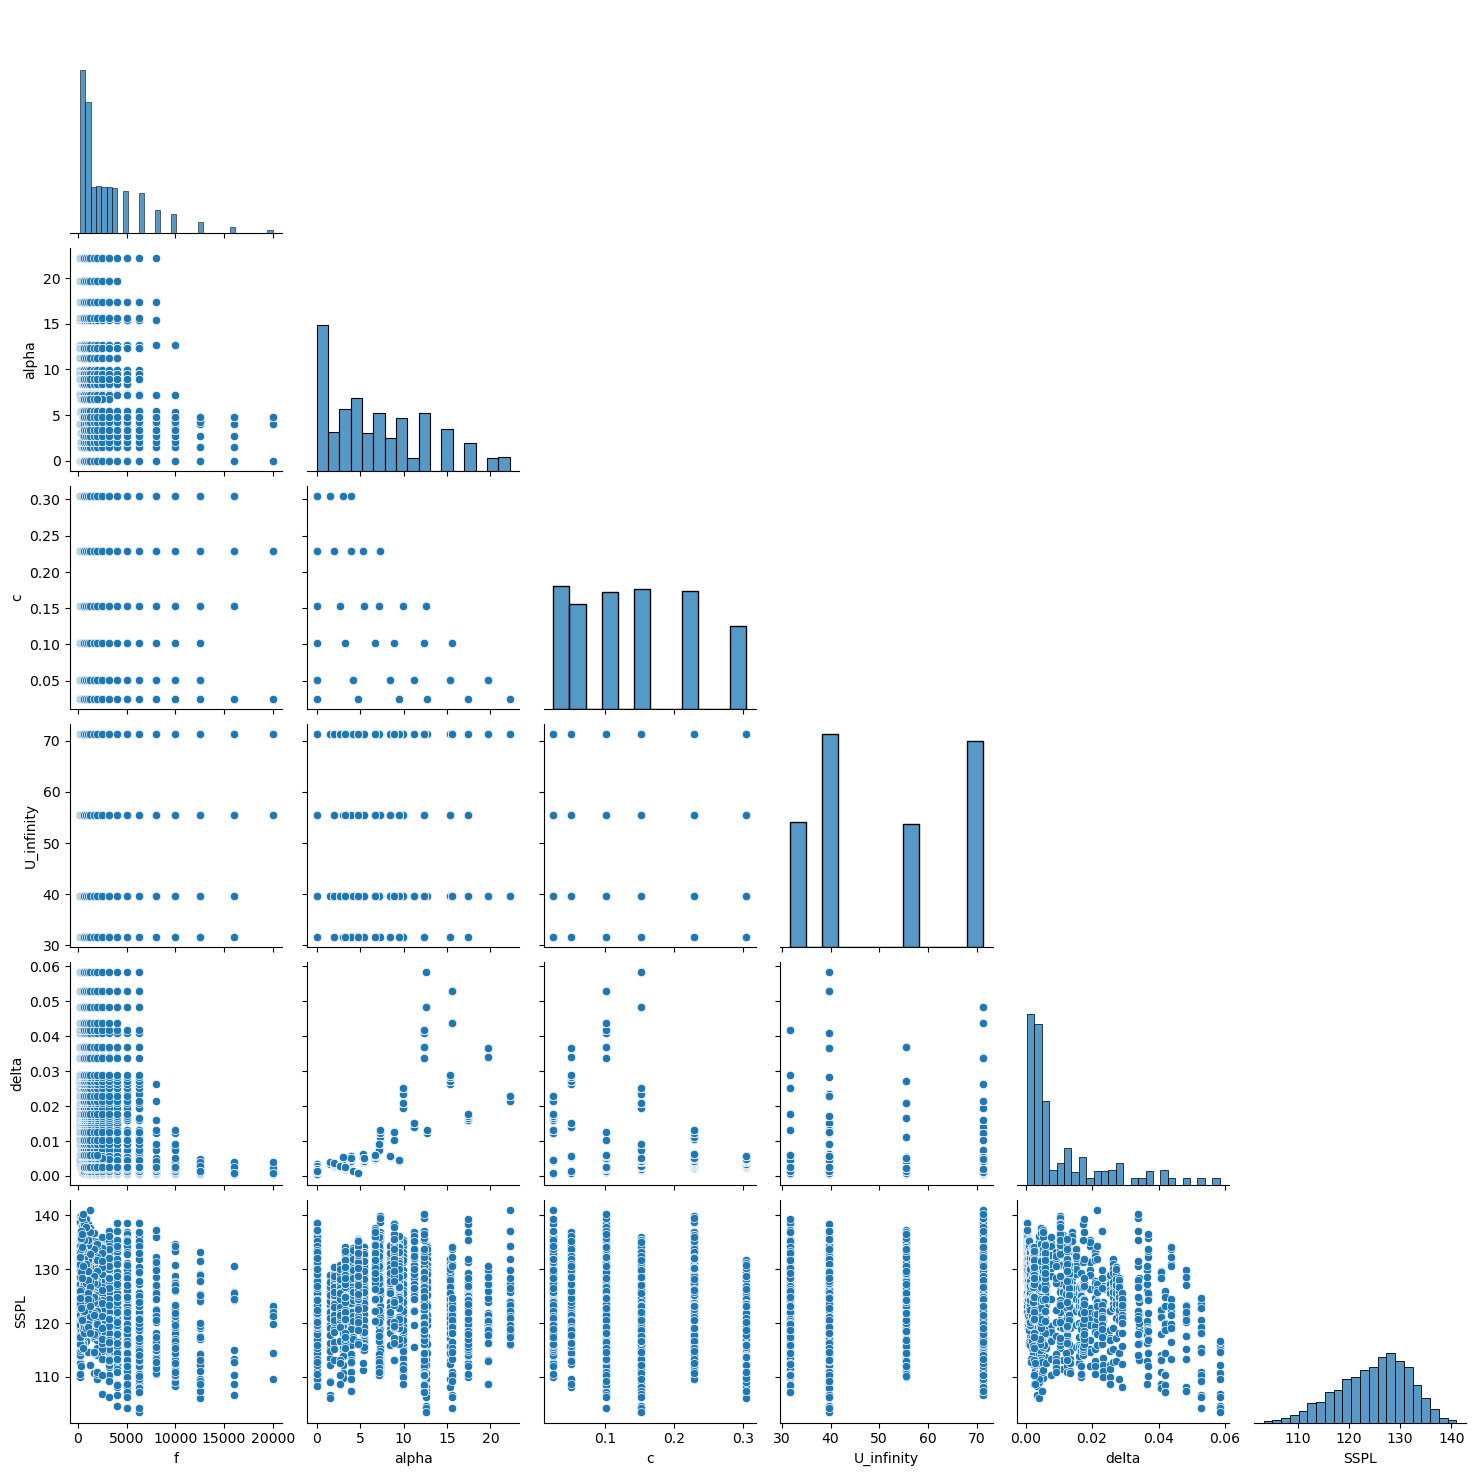

In [5]:
sns.pairplot(NASA_df, corner = True, diag_kind='hist')


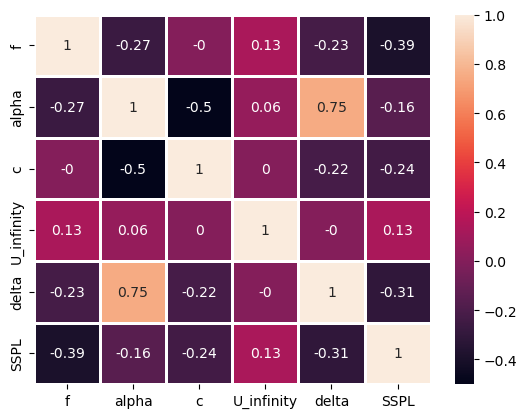

In [6]:
#Correlacion entre las features
correlacion_profit = NASA_df.corr().round(2)
sns.heatmap(data=correlacion_profit, linewidths=1, annot=True)
plt.show()

El pairplot no nos da mucha información por la naturaleza categorica de las variables, sin embargo, se puede intuir una correlación entre $\alpha$ y $\delta$.

Esto se comprueba en el mapa de calor donde se ve una alta correlación entre las variables antes mencionadas.

Por otro lado, se encuentra una alta correlación para dos variables claramente independientes por lo que vimos al inicio: el largo de cuerda (c) y el ángulo de ataque. Esto puede deberse a que haya un sesgo en el experimento y que sólo se hayan testeado ángulos de ataque altos para largos de cuerda altos. Esto último puede tener un sentido físico, ya que al modelo físico no le aporta más información, pero puede disminuir el rendimiento de un modelo de aprendizaje automático.


Por último, y adelantandonos al modelo de ML aplicado, empezamos a observar en los pairplots que no parece haber una relación matematica buena para que modelos basados en este principio se desempeñen de buena manera, lo que podría hacer a un bosque aleatorio una buena opción para este modelo.

Resulta interesante entonces probar modelso de diferentes naturalezas y observar cuál de los puntos mencionados tiene más peso en un modelo pequeño de ML.

## Ingeniería de Features

Luego del análisis exploratorio inicial, veamos si hacemos algún cambio en el dataset para manejar su estudio:

In [7]:
#Mantenemos el df incambiado
NASA_df_base = NASA_df.copy()

Veamos los siguientes puntos uno a uno:

* Tratamiento por datos faltantes, técnicas de imputación
* Eliminación de datos repetidos.
* Discretización de variables.
* Escalamiento de variables.
* Tratamiento de outliers.
* Reducción de dimensionalidad.
* Filtrado de variables.

### Imputación de datos

En este caso no contamos con datos faltantes por lo que no es necesaria ninguna técnica de reimputación

### Eliminación de datos duplicados

Veamos si hay algún dato duplicado

In [8]:
NASA_df.drop_duplicates()
NASA_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


No hay ningún dato repetido.

### Discretización de variables

De acuerdo a la baja cantidad de features que tenemos y que en su mayoría ya son variables discretizadas. No parece ser una buena opción para este dataset.

### Escalamiento de variables

En este caso si observamos una discrepancia en la escala de los datos de las diferentes variables, por lo que previo a cualquier modelo de regresión tendremos que usar un escalador.

### Tratamiento de outliers

Estudiemos si hay una presencia de outliers con el método intercuartilico.

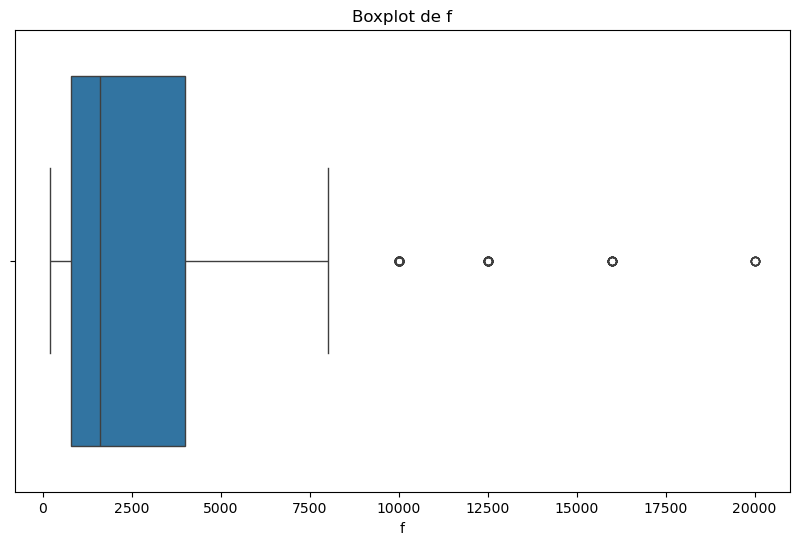

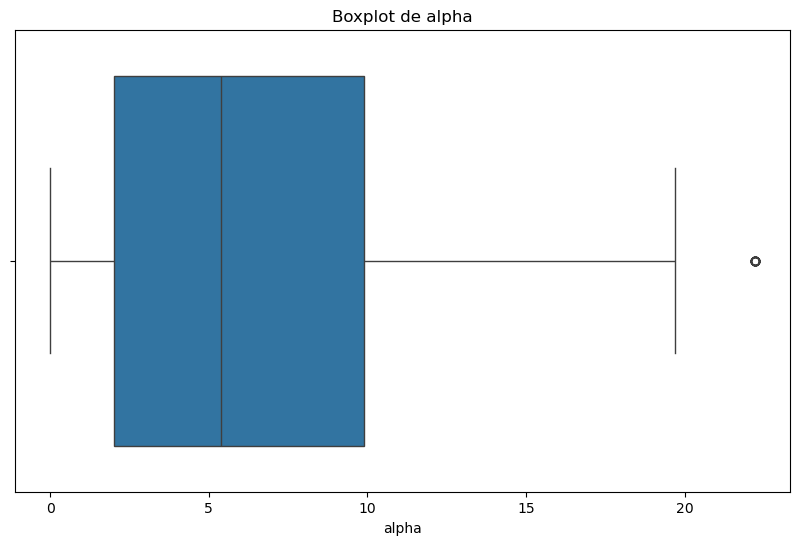

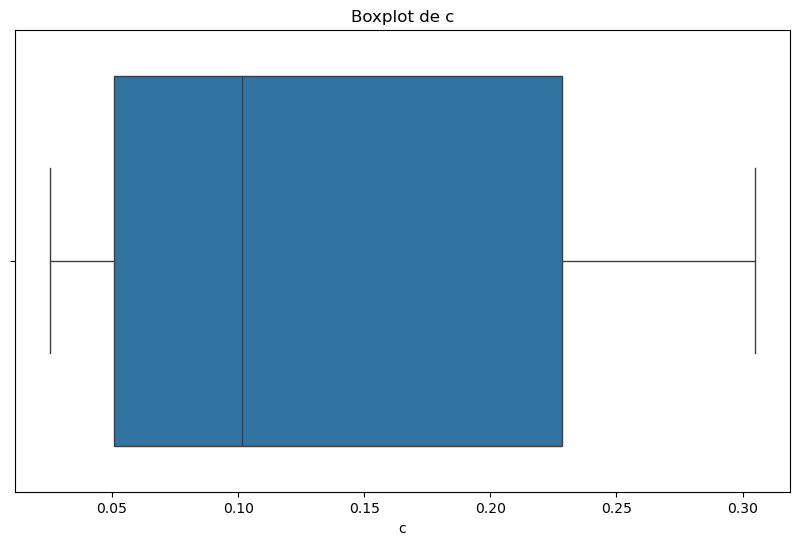

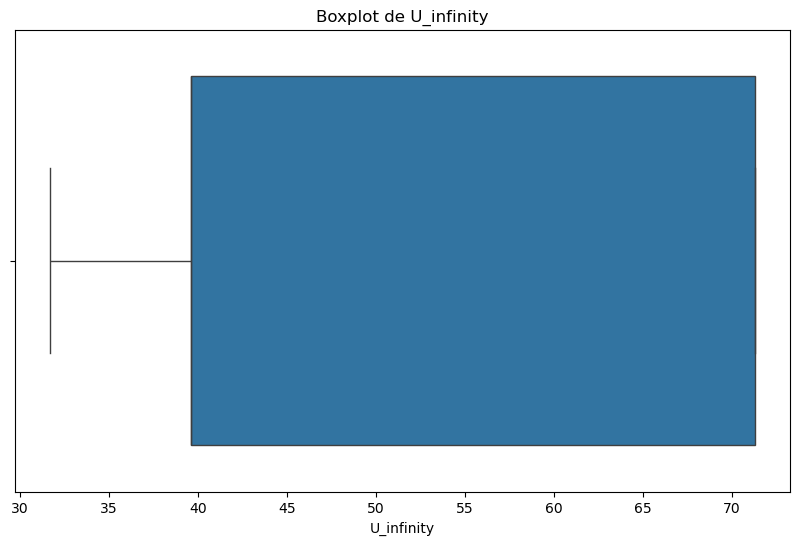

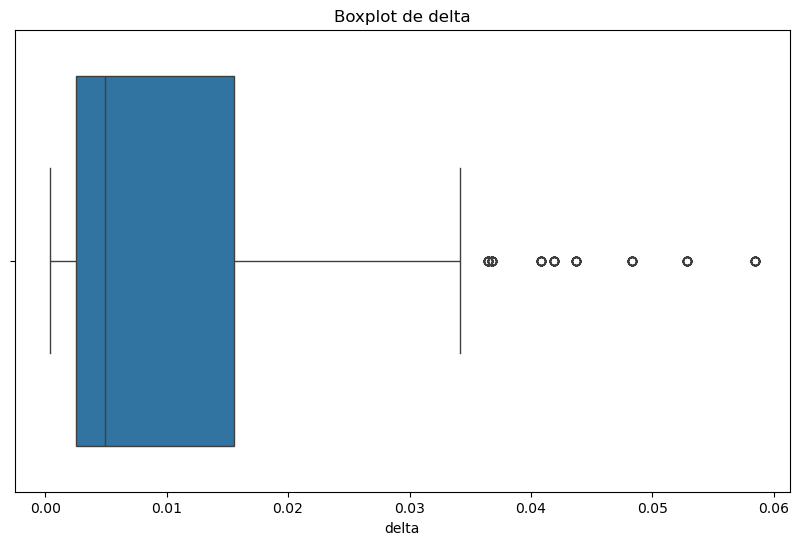

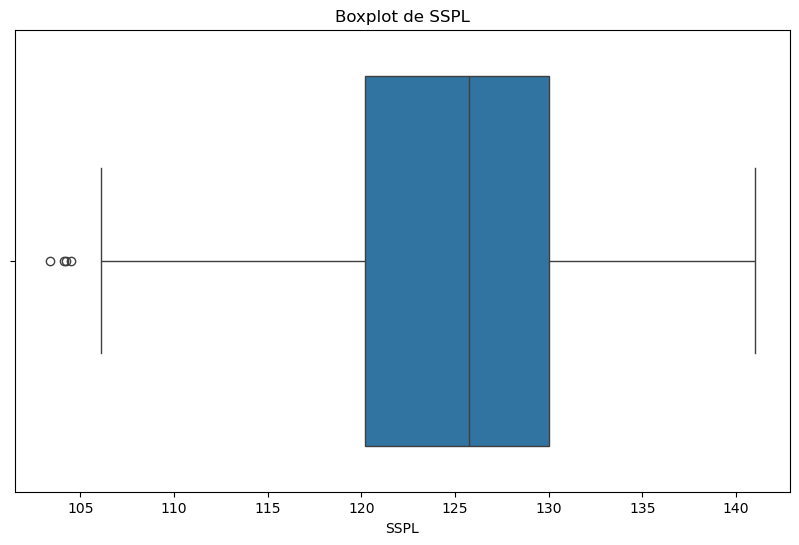

In [9]:
for feature in NASA_df.columns:
    plt.figure(figsize=(10, 6))  # Crear una nueva figura para cada boxplot
    sns.boxplot(x=NASA_df[feature])
    plt.title(f'Boxplot de {feature}')
    plt.xlabel(feature)
    plt.show()  # Mostrar el gráfico

En primer lugar es importante remarcar que no hay outliers propiamente dichos, es decir, dado que todos los valores salen de un experimento y que asumimos que no hay errores de medición en el dataset, todos los datos son *igual de válidos*. No obstante, me interesa estudiar los datos medidos en alta frecuencia y comprobar si coinciden con los datos de bajo ruido.

In [10]:
# Calculamos los cuartiles y el IQR para las columnas "f" y "SSPL"
Q1_f = NASA_df['f'].quantile(0.25)
Q3_f = NASA_df['f'].quantile(0.75)
IQR_f = Q3_f - Q1_f

Q1_SSPL = NASA_df['SSPL'].quantile(0.25)
Q3_SSPL = NASA_df['SSPL'].quantile(0.75)
IQR_SSPL = Q3_SSPL - Q1_SSPL

# Calculamos los límites superior e inferior para outliers
upper_limit_f = Q3_f + 1.5 * IQR_f
lower_limit_f = Q1_f - 1.5 * IQR_f

upper_limit_SSPL = Q3_SSPL + 1.5 * IQR_SSPL
lower_limit_SSPL = Q1_SSPL - 1.5 * IQR_SSPL

# Contamos los outliers en cada columna y sumamos los valores
outliers_f = NASA_df[(NASA_df['f'] > upper_limit_f) | (NASA_df['f'] < lower_limit_f)]['f'].count()
outliers_SSPL = NASA_df[(NASA_df['SSPL'] > upper_limit_SSPL) | (NASA_df['SSPL'] < lower_limit_SSPL)]['SSPL'].count()
cantidad_datos = NASA_df.shape[0]

# Mostramos los resultados
print(f"Número de outliers en 'f': {outliers_f}. Lo que representa un {outliers_f/cantidad_datos}")
print(f"Número de outliers en 'SSPL': {outliers_SSPL}. Lo que representa un {outliers_SSPL/cantidad_datos}")

Número de outliers en 'f': 86. Lo que representa un 0.057218895542248835
Número de outliers en 'SSPL': 4. Lo que representa un 0.0026613439787092482


Hay bastantes más datos outliers de f que de SSPL, veamos cuales son estos últimos.

In [11]:
NASA_df[(NASA_df['SSPL'] > upper_limit_SSPL) | (NASA_df['SSPL'] < lower_limit_SSPL)]


,f,alpha,c,U_infinity,delta,SSPL
722,4000,12.6,0.1524,39.6,0.058411,104.500
723,5000,12.6,0.1524,39.6,0.058411,104.130
724,6300,12.6,0.1524,39.6,0.058411,103.380
1502,6300,15.6,0.1016,39.6,0.052849,104.204


Podemos observar entonces que las observaciones que son outliers de SSPL no lo son en frecuencia, por lo tanto, son valores que aportan información del experimento.

De esta manera decidimos no quitar ninguna observación del dataset.

### Reducción de dimensionalidad

De acuerdo a lo visto en el heatmap hay una alta correlación entre delta y alpha, por lo que podría ser interesante estudiar reducir la dimensionalidad del problema reemplazando estos dos features por uno nuevo $\alpha$ _ $\delta$.

Para eso utilizaremos el método de componentes principales (PCA):

In [12]:
NASA_df_PCA = NASA_df.loc[:,['alpha', 'delta']]

pca = PCA(n_components=1)# Proyectamos de 2 a 1 dimensiones
pca.fit_transform(NASA_df_PCA)

pca.explained_variance_ratio_


array([0.99999787])

Por lo que con el nuevo componente no perdemos información y podemos reducir la dimensionalidad.

In [13]:
NASA_df_PCA =pca.fit_transform(NASA_df_PCA)

# Eliminamos las columnas 'alpha' y 'delta'
NASA_df = NASA_df.drop(columns=['alpha', 'delta'])

# Agregamos la nueva columna creada 'alpha_delta'
NASA_df['alpha_delta'] = NASA_df_PCA

NASA_df

,f,c,U_infinity,SSPL,alpha_delta
0,800,0.3048,71.3,126.201,-6.782307
1,1000,0.3048,71.3,125.201,-6.782307
2,1250,0.3048,71.3,125.951,-6.782307
3,1600,0.3048,71.3,127.591,-6.782307
4,2000,0.3048,71.3,127.461,-6.782307
...,...,...,...,...,...
1498,2500,0.1016,39.6,110.264,8.817755
1499,3150,0.1016,39.6,109.254,8.817755
1500,4000,0.1016,39.6,106.604,8.817755
1501,5000,0.1016,39.6,106.224,8.817755


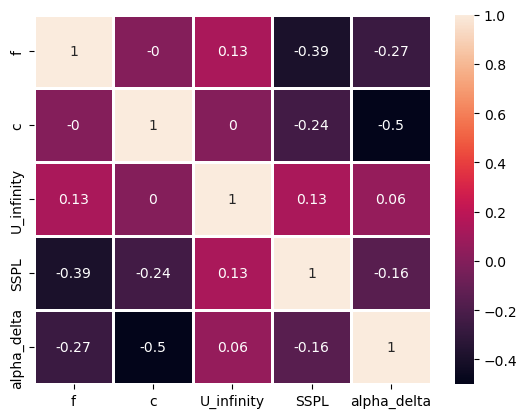

In [14]:
#Correlacion entre las features
correlacion_profit = NASA_df.corr().round(2)
sns.heatmap(data=correlacion_profit, linewidths=1, annot=True)
plt.show()

### Conclusiones

De acuerdo a los puntos principales en el análisis de datos, el dataset original solamente se vió modificado para reducir la dimensionalidad. Resulta de interés estudiar como este cambio impacta en los resultados del modelo.

## Separación Train-Test-Split

Separamos en train-test para el dataset base: 

In [15]:
#Datos Base
X_base = NASA_df_base.iloc[:,:-1].values
y_base = NASA_df_base.iloc[:,-1].values

In [16]:
#Datos Base

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.3, random_state=42)

In [17]:
#Escalamos a una normal

from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train_base = sc_X.fit_transform(X_train_base)
X_test_base = sc_X.transform(X_test_base)

Y ahora lo mismo con el dataset modificado:

In [18]:
X = NASA_df.drop(columns=["SSPL"]).values
y = NASA_df["SSPL"].values


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [20]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

## Modelos de Aprendizaje Automático

Creamos un df para ir llevando las métricas de rendimiento:

In [21]:
#Dataframe de métricas
col = ['Modelo','Tipo','MAE','RMSE','MAPE','R_2']
df_metricas = pd.DataFrame(columns=col)

### Regresión Lineal

Veamos ahora como se comporta una regresión lineal:

In [22]:
# Creando el modelo de regresión lineal simple:
regresion = LinearRegression()

In [23]:
# Y lo entrenamos, con el set de entrenamiento
regresion.fit(X_train_base, y_train_base)

LinearRegression()

In [24]:
#Primero obtenemos las predicciones del modelo
y_pred_base_lr = regresion.predict(X_test_base)
mae = mean_absolute_error(y_test_base, y_pred_base_lr)
rmse = np.sqrt(mean_squared_error(y_test_base, y_pred_base_lr))
mape = mean_absolute_percentage_error(y_test_base, y_pred_base_lr)
r_2 = r2_score(y_test_base, y_pred_base_lr)

df_metricas.loc[len(df_metricas)] = ["Regresión Lineal", "Base", mae, rmse, mape, r_2]

In [25]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.77618,4.867017,0.030487,0.498273


In [26]:
# Creando el modelo de regresión lineal simple:
regresion = LinearRegression()

In [27]:
# Y lo entrenamos, con el set de entrenamiento
regresion.fit(X_train, y_train)

LinearRegression()

In [28]:
#Primero obtenemos las predicciones del modelo
y_pred_lr = regresion.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape = mean_absolute_percentage_error(y_test, y_pred_lr)
r_2 = r2_score(y_test, y_pred_lr)

df_metricas.loc[len(df_metricas)] = ["Regresión Lineal", "Modificado", mae, rmse, mape, r_2]

In [29]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397


Contrario a lo que me esperaba el modelo performa levemente peor al haberle hecho la descompsición por componentes principales. Como se intuía en un principio el modelo en general no parece performar muy bien con errores altos, busquemos una manera de poder observar mejor estos errores.

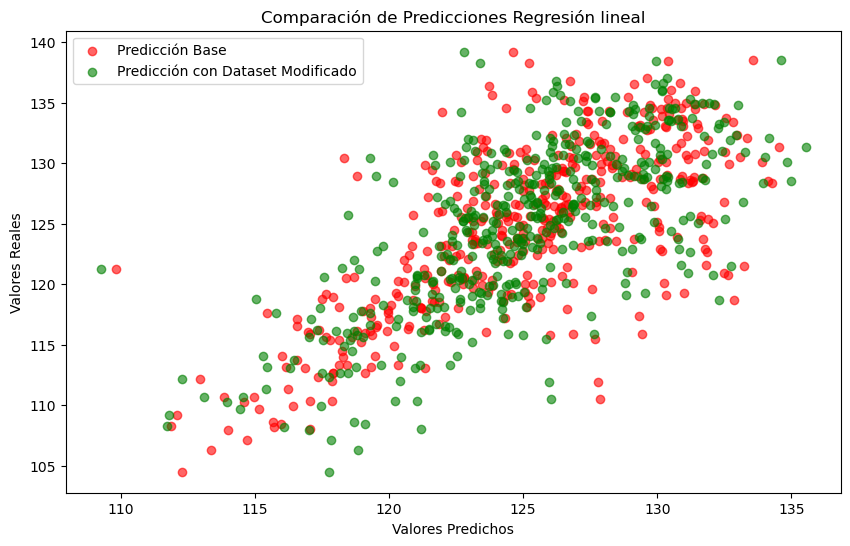

In [30]:
# Crear el scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot para y_pred_base en rojo
plt.scatter(y_pred_base_lr, y_test_base, color='red', label='Predicción Base', alpha=0.6)

# Scatter plot para y_pred en verde
plt.scatter(y_pred_lr, y_test, color='green', label='Predicción con Dataset Modificado', alpha=0.6)

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones Regresión lineal')
plt.legend()

# Mostrar la gráfica
plt.show()

En la gráfica anterior podemos observar que ambos modelos predicen de manera muy similar, lo que ya veiamos con las métricas. La diferencia se puede notar en que a los valores reales más chicos (que ya habíamos observado que eran los outliers del dataset), el modelo con PCA los toma más altos y por lo tanto el error es mayor.

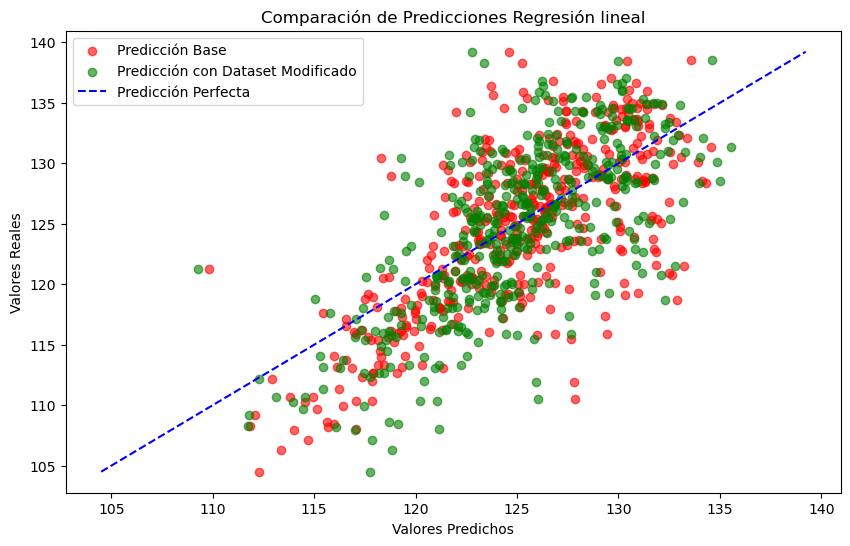

In [31]:
# Crear el scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot para y_pred_base en rojo
plt.scatter(y_pred_base_lr, y_test_base, color='red', label='Predicción Base', alpha=0.6)

# Scatter plot para y_pred en verde
plt.scatter(y_pred_lr, y_test, color='green', label='Predicción con Dataset Modificado', alpha=0.6)

# Añadir la línea y=x
# Definir los límites del gráfico
x_min = min(min(y_pred_base_lr), min(y_pred_lr), min(y_test))
x_max = max(max(y_pred_base_lr), max(y_pred_lr), max(y_test))

# Crear un array de valores x para la línea y=x
x = np.linspace(x_min, x_max, 100)
plt.plot(x, x, color='blue', linestyle='--', label='Predicción Perfecta')

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones Regresión lineal')
plt.legend()

# Mostrar la gráfica
plt.show()

En la última gráfica lo que se muestra es en la línea azul la predicción "perfecta", se puede observar la relación lineal sobretodo en los valores entre 120 y 130 db, pero con mayor error en los extremos.

El modelo tiende a agrupar las predicciones a valores medios, y recordando la primera parte de este trabajo, parece ser que el modelo intenta modelar uno de los tipos de ruido y proyecta hacia el resto de predicciones erroneamente.

Veamos si esto se sigue observando en un modelo SVR.

### Support Vector Machine Regresión

Probemos ahora un SVM de regresión, para ello primero busquemos cuales son los mejores parámetros (lo estudio con el df modificado):

In [32]:
svm_NASA = SVR()

#Comentado para disminuir tiempo de procesamiento
'''grid = GridSearchCV(svm_NASA,
                    [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "gamma": [0.1, 0.5, 1, 2, 10, 100], "kernel": ["rbf"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], "kernel": ["poly"]}],
                    refit=True,
                    cv=5,
                    scoring='f1')
grid.fit(X_train,y_train)'''

'grid = GridSearchCV(svm_NASA,\n                    [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"]},\n                     {"C": [0.01, 0.1, 1, 5, 10, 100], "gamma": [0.1, 0.5, 1, 2, 10, 100], "kernel": ["rbf"]},\n                     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], "kernel": ["poly"]}],\n                    refit=True,\n                    cv=5,\n                    scoring=\'f1\')\ngrid.fit(X_train,y_train)'

In [33]:
# Los mejores parametros resultaron ser los siguientes

svm_best_params = {'C': 0.01, 'kernel': 'linear'}

In [34]:
svm_NASA_best = SVR(**svm_best_params) #Le paso como diccionario los mejores parámetros
svm_NASA_best.fit(X_train_base, y_train_base)


SVR(C=0.01, kernel='linear')

In [35]:
y_pred_base_svr = svm_NASA_best.predict(X_test_base)
mae = mean_absolute_error(y_test_base, y_pred_base_svr)
rmse = np.sqrt(mean_squared_error(y_test_base, y_pred_base_svr))
mape = mean_absolute_percentage_error(y_test_base, y_pred_base_svr)
r_2 = r2_score(y_test_base, y_pred_base_svr)

df_metricas.loc[len(df_metricas)] = ["SVR", "Base", mae, rmse, mape, r_2]

In [36]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942


In [37]:
svm_NASA_best = SVR(**svm_best_params) 
svm_NASA_best.fit(X_train, y_train)


SVR(C=0.01, kernel='linear')

In [38]:
y_pred_svr = svm_NASA_best.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mape = mean_absolute_percentage_error(y_test, y_pred_svr)
r_2 = r2_score(y_test, y_pred_svr)

df_metricas.loc[len(df_metricas)] = ["SVR", "Modificado", mae, rmse, mape, r_2]


In [39]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285


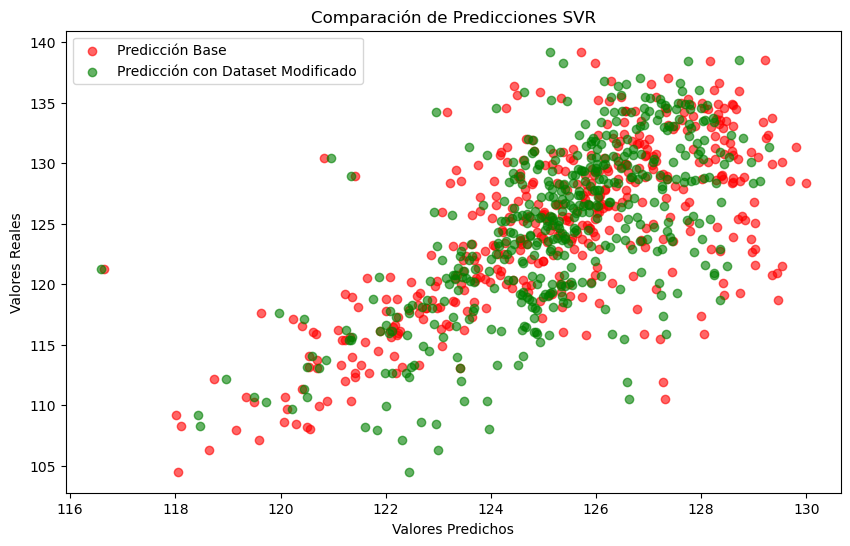

In [40]:
# Crear el scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot para y_pred_base en rojo
plt.scatter(y_pred_base_svr, y_test_base, color='red', label='Predicción Base', alpha=0.6)

# Scatter plot para y_pred en verde
plt.scatter(y_pred_svr, y_test, color='green', label='Predicción con Dataset Modificado', alpha=0.6)

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones SVR')
plt.legend()

# Mostrar la gráfica
plt.show()

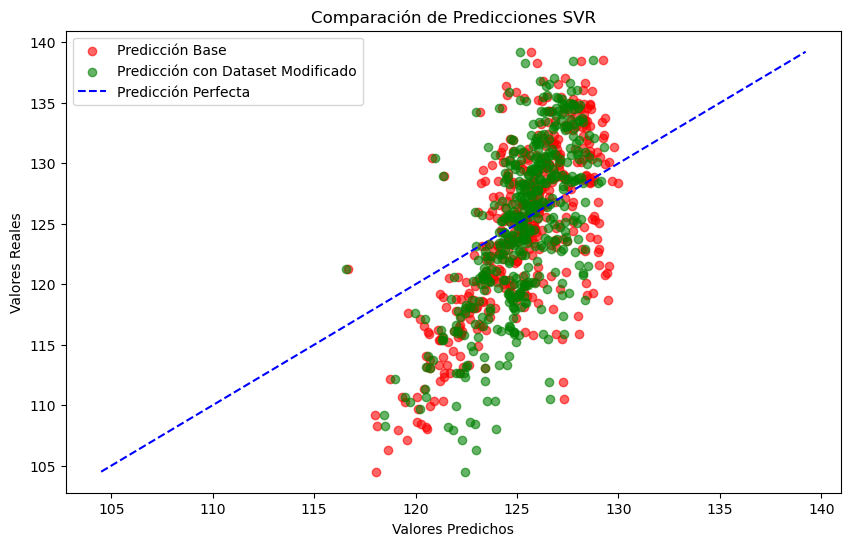

In [41]:
# Crear el scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot para y_pred_base en rojo
plt.scatter(y_pred_base_svr, y_test_base, color='red', label='Predicción Base', alpha=0.6)

# Scatter plot para y_pred en verde
plt.scatter(y_pred_svr, y_test, color='green', label='Predicción con Dataset Modificado', alpha=0.6)

# Añadir la línea y=x
# Definir los límites del gráfico
x_min = min(min(y_pred_base_svr), min(y_pred_svr), min(y_test))
x_max = max(max(y_pred_base_svr), max(y_pred_svr), max(y_test))

# Crear un array de valores x para la línea y=x
x = np.linspace(x_min, x_max, 100)
plt.plot(x, x, color='blue', linestyle='--', label='Predicción Perfecta')

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones SVR')
plt.legend()

# Mostrar la gráfica
plt.show()

Lo observado con el modelo de regresión lineal se profundiza aún más en el modelo de SVR, el modelo agrupa mucho las predicciones en los valores medios y tiende a tener errores grandes para los valores extremos.

Como intuiamos en un principio modelos puramente matemáticos no parecen performar muy bien por su naturaleza de querer encontrar una "fórmula" que englobe al problema, pero como sabemos del principio el problema sí es gobernado por fórmulas físicas pero no una única.

Veamos ahora como performar otros tipos de modelos como XGBoost y Bosques aleatorios:

### Árbol de Regresión

Usaremos el modelo de árbol de regresión simplemente para tener uno base y luego comparar con XGBoost y Bosque Aleatorio

In [42]:
# Entrenamos el arbol de regresión
tree_regressor = DecisionTreeRegressor(splitter='best', max_depth=13, min_samples_split=2,
                                       min_samples_leaf=16, random_state=42)

tree_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=13, min_samples_leaf=16, random_state=42)

In [43]:
# Calculamos las métricas
y_pred_tree = tree_regressor.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mape = mean_absolute_percentage_error(y_test, y_pred_tree)
r_2 = r2_score(y_test, y_pred_tree)

df_metricas.loc[len(df_metricas)] = ["Árbol de Regresión", "Modificado", mae, rmse, mape, r_2]

In [44]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285
4,Árbol de Regresión,Modificado,3.401030,4.384855,0.027477,0.592758


Sin hacer ninguna búsqueda de hiperparámetros y un modelo muy simple como son los árboles de decisión, ya performa mejor que lo visto en Regresión Lineal o SVM de regresión.

Veamos ahora si podemos mejorar esto:

### XGBoost

Mantengamos la misma idea de trabajo como veniamos con los modelos anteriores, primero estudiamos con los datos base y luego con el modificado:

In [45]:
# Inicializamos XGBoost con sus hiperparámetros por defecto
xgb_regressor_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
xgb_regressor_base.fit(X_train_base, y_train_base)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [46]:
y_pred_base_xgb = xgb_regressor_base.predict(X_test_base)
mae = mean_absolute_error(y_test_base, y_pred_base_xgb)
rmse = np.sqrt(mean_squared_error(y_test_base, y_pred_base_xgb))
mape = mean_absolute_percentage_error(y_test_base, y_pred_base_xgb)
r_2 = r2_score(y_test_base, y_pred_base_xgb)

df_metricas.loc[len(df_metricas)] = ["XGBoost", "Base", mae, rmse, mape, r_2]

In [47]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285
4,Árbol de Regresión,Modificado,3.401030,4.384855,0.027477,0.592758
5,XGBoost,Base,1.154811,1.668564,0.009343,0.941030


In [48]:
# Inicializamos XGBoost con sus hiperparámetros por defecto
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
xgb_regressor.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [49]:
y_pred_xgb = xgb_regressor.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape = mean_absolute_percentage_error(y_test, y_pred_xgb)
r_2 = r2_score(y_test, y_pred_xgb)

df_metricas.loc[len(df_metricas)] = ["XGBoost", "Modificado", mae, rmse, mape, r_2]

In [50]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285
4,Árbol de Regresión,Modificado,3.401030,4.384855,0.027477,0.592758
5,XGBoost,Base,1.154811,1.668564,0.009343,0.941030
6,XGBoost,Modificado,1.178002,1.686315,0.009482,0.939769


El modelo performa considerablemente mejor, se disminuye a menos de un tercio el error medio absoluto del mejor modelo anterior (regresión lineal).

Parece ser que este modelo sí logra diferenciar los tipos de ruido en su predicción, veamos el gráfico siguiente:

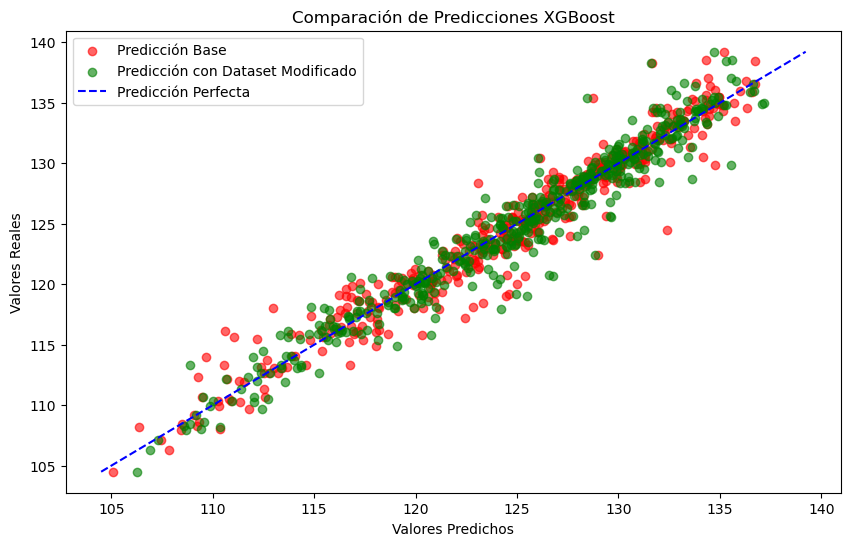

In [51]:
# Crear el scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot para y_pred_base en rojo
plt.scatter(y_pred_base_xgb, y_test_base, color='red', label='Predicción Base', alpha=0.6)

# Scatter plot para y_pred en verde
plt.scatter(y_pred_xgb, y_test, color='green', label='Predicción con Dataset Modificado', alpha=0.6)

# Añadir la línea y=x
# Definir los límites del gráfico
x_min = min(min(y_pred_base_svr), min(y_pred_svr), min(y_test))
x_max = max(max(y_pred_base_svr), max(y_pred_svr), max(y_test))

# Crear un array de valores x para la línea y=x
x = np.linspace(x_min, x_max, 100)
plt.plot(x, x, color='blue', linestyle='--', label='Predicción Perfecta')

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones XGBoost')
plt.legend()

# Mostrar la gráfica
plt.show()

Es realmente sorprendente lo bien que performa el modelo XGBoost viniendo de resultados tan pobres con LR y SVR. No presenta los problemas que veiamos de agrupar los datos en los valores centrales.

Con respecto a las diferencias entre el dataset base y el modificado, prácticamente no se encuentra nada significativo. Por comentar algo visual, el modificado tiene menos error en valores menores de dB, mientras que lo contrario sucede en los datos mayores.

Veamos el último modelo a estudiar que es un Random Forest

### Random Forest Regresión 

Hacemos igual que con SVR, primero buscamos los mejores parametros y después entrenamos con eso el modelo base y el modificado.

In [52]:
rf_NASA = RandomForestRegressor()

#Comentado para disminuir tiempo de procesamiento
'''
grid = GridSearchCV(rf_NASA,
                    [{'n_estimators': [50, 100, 200, 300],
                     'max_depth': [None, 5, 10, 20],
                     'min_samples_split': [2, 5, 10, 15],
                     'min_samples_leaf': [1, 2, 4, 6]}],
                    refit=True,
                    cv=5,
                    scoring='f1')
grid.fit(X_train,y_train)'''

"\ngrid = GridSearchCV(rf_NASA,\n                    [{'n_estimators': [50, 100, 200, 300],\n                     'max_depth': [None, 5, 10, 20],\n                     'min_samples_split': [2, 5, 10, 15],\n                     'min_samples_leaf': [1, 2, 4, 6]}],\n                    refit=True,\n                    cv=5,\n                    scoring='f1')\ngrid.fit(X_train,y_train)"

In [53]:
rf_best_params = {'max_depth': None,
                  'min_samples_leaf': 1,
                  'min_samples_split': 2,
                  'n_estimators': 50}

Primero estudiemos el modelo base:


In [54]:
rf_NASA_base_best = RandomForestRegressor(**rf_best_params, random_state=42) 
rf_NASA_base_best.fit(X_train_base, y_train_base)

RandomForestRegressor(n_estimators=50, random_state=42)

In [55]:
y_pred_base_rf = rf_NASA_base_best.predict(X_test_base)
mae = mean_absolute_error(y_test_base, y_pred_base_rf)
rmse = np.sqrt(mean_squared_error(y_test_base, y_pred_base_rf))
mape = mean_absolute_percentage_error(y_test_base, y_pred_base_rf)
r_2 = r2_score(y_test_base, y_pred_base_rf)

df_metricas.loc[len(df_metricas)] = ["Bosque Aleatorio", "Base", mae, rmse, mape, r_2]

In [56]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285
4,Árbol de Regresión,Modificado,3.401030,4.384855,0.027477,0.592758
5,XGBoost,Base,1.154811,1.668564,0.009343,0.941030
6,XGBoost,Modificado,1.178002,1.686315,0.009482,0.939769
7,Bosque Aleatorio,Base,1.353108,1.869731,0.010930,0.925954


Y con el dataset modificado:

In [57]:
rf_NASA_best = RandomForestRegressor(**rf_best_params, random_state=42) 
rf_NASA_best.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [58]:
y_pred_rf = rf_NASA_best.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape = mean_absolute_percentage_error(y_test, y_pred_rf)
r_2 = r2_score(y_test, y_pred_rf)

df_metricas.loc[len(df_metricas)] = ["Bosque Aleatorio", "Modificado", mae, rmse, mape, r_2]

In [59]:
df_metricas

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285
4,Árbol de Regresión,Modificado,3.401030,4.384855,0.027477,0.592758
5,XGBoost,Base,1.154811,1.668564,0.009343,0.941030
6,XGBoost,Modificado,1.178002,1.686315,0.009482,0.939769
7,Bosque Aleatorio,Base,1.353108,1.869731,0.010930,0.925954
8,Bosque Aleatorio,Modificado,1.447709,2.008596,0.011684,0.914547


El modelo del bosque performa levemente peor que XGBoost, pero siguen siendo buenos resultados y notoriamente superiores a lo visto en regresión lineal o SVR.

Sigue siendo el dataset modificado peor en resultados que el original.

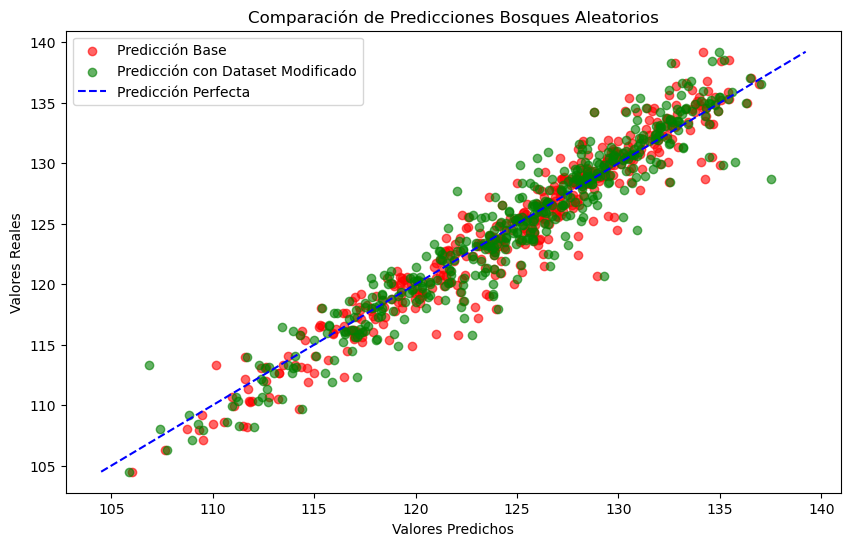

In [60]:
# Crear el scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot para y_pred_base en rojo
plt.scatter(y_pred_base_rf, y_test_base, color='red', label='Predicción Base', alpha=0.6)

# Scatter plot para y_pred en verde
plt.scatter(y_pred_rf, y_test, color='green', label='Predicción con Dataset Modificado', alpha=0.6)

# Añadir la línea y=x
# Definir los límites del gráfico
x_min = min(min(y_pred_base_svr), min(y_pred_svr), min(y_test))
x_max = max(max(y_pred_base_svr), max(y_pred_svr), max(y_test))

# Crear un array de valores x para la línea y=x
x = np.linspace(x_min, x_max, 100)
plt.plot(x, x, color='blue', linestyle='--', label='Predicción Perfecta')

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones Bosques Aleatorios')
plt.legend()

# Mostrar la gráfica
plt.show()

Se observa lo esperado en la gráfica, buenos resultados pero distintivamente peores que los de XGBoost. 

## Conclusiones

Comparemos en un gráfico todas las predicciones de los diferentes modelos.

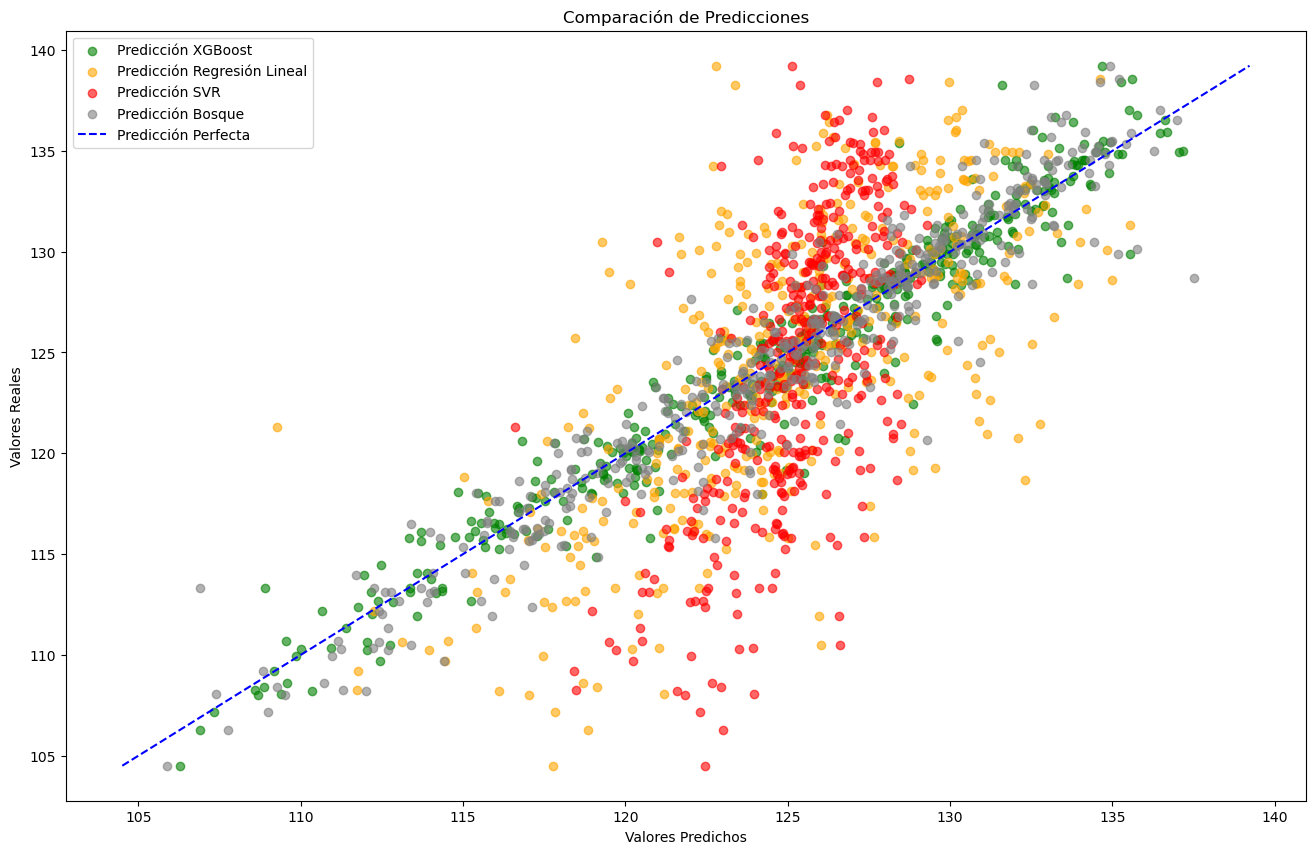

In [61]:
# Crear el scatter plot
plt.figure(figsize=(16, 10))

# Scatter plot para XGBoost en verde
plt.scatter(y_pred_xgb, y_test, color='green', label='Predicción XGBoost', alpha=0.6)

# Scatter plot para LR en naranja
plt.scatter(y_pred_lr, y_test, color='orange', label='Predicción Regresión Lineal', alpha=0.6)

# Scatter plot para SVR en rojo
plt.scatter(y_pred_svr, y_test, color='red', label='Predicción SVR', alpha=0.6)

# Scatter plot para RF en gris
plt.scatter(y_pred_rf, y_test, color='grey', label='Predicción Bosque', alpha=0.6)

# Añadir la línea y=x
# Definir los límites del gráfico
x_min = min(min(y_pred_base_svr), min(y_pred_svr), min(y_test))
x_max = max(max(y_pred_base_svr), max(y_pred_svr), max(y_test))

# Crear un array de valores x para la línea y=x
x = np.linspace(x_min, x_max, 100)
plt.plot(x, x, color='blue', linestyle='--', label='Predicción Perfecta')

# Añadir etiquetas y título
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.title('Comparación de Predicciones')
plt.legend()

# Mostrar la gráfica
plt.show()

Es interesante observar la clara distinción de distribuciones entre los modelos matemáticos y los descendientes de árboles de decisión. Hay una zona "central" dónde mejora un poco el modelo matemático, pero muestra errores muy grandes en valores más extremos. 

Esto mismo lo podemos ver en nuestro dataframe de métricas:

In [62]:
df_metricas.sort_values(by="MAE", ascending=True)

,Modelo,Tipo,MAE,RMSE,MAPE,R_2
5,XGBoost,Base,1.154811,1.668564,0.009343,0.941030
6,XGBoost,Modificado,1.178002,1.686315,0.009482,0.939769
7,Bosque Aleatorio,Base,1.353108,1.869731,0.010930,0.925954
8,Bosque Aleatorio,Modificado,1.447709,2.008596,0.011684,0.914547
4,Árbol de Regresión,Modificado,3.401030,4.384855,0.027477,0.592758
0,Regresión Lineal,Base,3.776180,4.867017,0.030487,0.498273
1,Regresión Lineal,Modificado,3.937213,4.981475,0.031873,0.474397
2,SVR,Base,4.443870,5.471336,0.036191,0.365942
3,SVR,Modificado,4.706760,5.817041,0.038399,0.283285


Un objetivo personal de este TP era poder integrar un análisis de datos aprendido en esta especialización con un análisis teórico de mi área de expertise. En particular, hubo dos puntos que resultaban interesante estudiar:

1. **Delta como función de otros features:** Esto lo mencionamos en el análisis teórico y con un simple mapa de calor se logró observar esta dependencia. Tratando de imaginarme esto como un "negocio" no pareció valer la pena, pues me llevó mucho más tiempo el estudio para poder llegar a esa conclusión que se podía lograr sin tener conocimientos teóricos del tema.
2. **Tipos de ruido:** En este caso se comentó en un inicio que el ruido autoprovocado por el álabe surgía de cinco fenómenos físicos diferentes. Esto claramente se observó en lás métricas de los diferentes modelos. Los modelos matemáticos no lograron resolver el problema, pues estaban buscando una solución que englobe todo el dataset y ya sabíamos que eso no era posible. Mientras que modelos basados en árboles de decisión, intrínsecamente logran "encontrar" y separar estos tipos de ruido, lo que hizo que performaran mucho mejor a lo largo de todo el rango del dataset. Más allá del ejercicio (donde la idea es probarlos diferentes tipos de modelo) se podía haber descartado de inicio los modelos de LR y SVR, y centrar todo el trabajo en XGBoost por ejemplo, para este caso en un "negocio" si parecería valioso entender el fenómeno detrás.

Como conclusión adicional se observa que la reducción de dimensionalidad no fue productiva a nivel de desempeño de modelos, en todos los casos el modelo performó peor que con el database sin modificar, esto puede deberse a aumentar el error de sesgo teniendo menos features. También habría que ser un poco más preciso en temas de procesamiento, para poder medir tiempos de entrenamiento de modelo y sobretodo búsqueda de parámetros ahorrados con un dataset con menos features. Esto último en mi caso no lo hice, porque veía mucha varianza al medir tiempo de ejecución de las mismas celdas.

También quiero mencionar que considero fue un acierto no quitar outliers. Aunque parecía tentador podar datos, modelos como XGBoost lograron predecir de bastante buena manera valores extremos del dataset y creo que fue información de estas observaciones fue valiosa.

Como pensamientos finales, este TP estuvo muy interesante pues me permitió mezclar dos áreas de conocimiento, además usando las herramientas que aprendimos en el curso no sólo logré encontrar un modelo que se desempeñara muy bien para este problema sino que pude entender porque uno puede desempeñarse mejor que otro.

## Otro enfoque al problema

Con las conclusiones el TP ya lo doy por finalizado, sin embargo quiero poder comentar esto. Viendo que los modelos de regresión son muy malos porque no logran clasificar el tipo de ruido, este dataset podría usarse no para predecir el ruido autegenerado, sino para un modelo No Supervisado y poder encontrar estos 5 tipos de ruido mencionados.

Creo que puede ser muy interesante porque se puede pensar como un modelo no supervisado, pero que si uno va detenidamente a las fuentes puede intentar "clasificar" el dataset y comparar con un modelo t-sne.

Podrán modelos matemáticos mejorar su desempeño si yo los estudio por tipos de ruido separado? O XGBoost seguirá siendo superior?